# Intermediate Feature Fusion Pipeline

This notebook implements intermediate fusion by using separate neural network branches for audio and tapping features before combining them. The audio and tapping features are first processed through their own branch MLPs to extract intermediate representations, which are then concatenated and fed into a fusion MLP for final classification.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

# EarlyFusion models
from FusionModels.IntermediateFusionMLP import *
from FusionModels.utils import cross_validation_5fold_intermediate_fusion, hyperparameter_tuning_intermediate_fusion

## 2. Data Preparation & Balancing

The audio and tapping features dataframes need to be balanced to ensure each patient has the same number of trials in both modalities. This is necessary because:
- Each patient may have a different number of audio trials vs. tapping trials
- The intermediate fusion model requires aligned trial counts across modalities

For each patient, we randomly downsample the modality with more trials to match the minimum trial count. This ensures proper alignment during training and evaluation.

In [ ]:
AUDIO_FEATURES = "/mloscratch/users/gnahas/data/features/acoustic_features_vf.csv"
TAPPING_FEATURES = "/mloscratch/users/clerget/data/csv/tapping_combined_features_session.csv"

audio_features = pd.read_csv(AUDIO_FEATURES)
tapping_features = pd.read_csv(TAPPING_FEATURES)

# Rename 'healthcode' to 'healthCode' for consistency if needed
if 'healthcode' in audio_features.columns and 'healthCode' not in audio_features.columns:
    audio_features = audio_features.rename(columns={'healthcode': 'healthCode'})

if 'healthcode' in tapping_features.columns and 'healthCode' not in tapping_features.columns:
    tapping_features = tapping_features.rename(columns={'healthcode': 'healthCode'})

# Count occurrences of trials per patient in each dataframe
counts_audio = audio_features["healthCode"].value_counts()
counts_tapping = tapping_features["healthCode"].value_counts()

# Consider healthCodes present in both files
shared_healthCodes = counts_audio.index.intersection(counts_tapping.index)

# Helper: minimum count of trials for each patient
min_counts = {code: min(counts_audio[code], counts_tapping[code]) for code in shared_healthCodes}

# Dropping extra audio trials per patient where needed
counts_audio_balanced = (
    audio_features[audio_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Dropping extra tapping trials per patient where needed
counts_tapping_balanced = (
    tapping_features[tapping_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Sort both dataframes by healthCode to ensure alignment
counts_audio_balanced = counts_audio_balanced.sort_values("healthCode").reset_index(drop=True)
counts_tapping_balanced = counts_tapping_balanced.sort_values("healthCode").reset_index(drop=True)

# Verify that there are the same amount of trials in both dataframes
print("Balanced trials count match:", len(counts_audio_balanced) == len(counts_tapping_balanced))

# Verify that healthCodes are properly aligned
print("Columns aligned:", all(
    counts_audio_balanced["healthCode"].values == counts_tapping_balanced["healthCode"].values
))

counts_audio_balanced.to_csv("/tremor2tensor/src_GAMMA/intermediate_features_audio.csv", index=False)
counts_tapping_balanced.to_csv("/tremor2tensor/src_GAMMA/intermediate_features_tapping.csv", index=False)

/tmp/ipykernel_23186/4267139489.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
/tmp/ipykernel_23186/4267139489.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))


Balanced trials count match: True
Columns aligned: True


In [ ]:
audio = pd.read_csv("/tremor2tensor/src_GAMMA/intermediate_features_audio.csv")
tapping = pd.read_csv("/tremor2tensor/src_GAMMA/intermediate_features_tapping.csv")
merged = pd.read_csv("/tremor2tensor/src_GAMMA/fusion_features.csv")

print(len(audio), len(tapping), len(merged))

14628 14628 14628


## 3. Data Loading

Load the balanced features from the previous step, along with labels and cross-validation fold assignments. These files define:
- Audio and tapping features (balanced trials per patient)
- Patient labels (PD vs. Control)
- Train/validation/test splits for 5-fold cross-validation

In [ ]:
AUDIO_FUSION_FEATURES = "/tremor2tensor/src_GAMMA/intermediate_features_audio.csv"
TAPPING_FUSION_FEATURES = "/tremor2tensor/src_GAMMA/intermediate_features_tapping.csv"
LABELS = "/tremor2tensor/src_GAMMA/paired_healthcode.csv"
TRAIN_FOLDS = "/tremor2tensor/src_GAMMA/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_train.csv"
VAL_TEST_FOLDS = "/tremor2tensor/src_GAMMA/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_val_test.csv"

## 4. Cross-Validation & Hyperparameter Tuning 

Using the specified 5-folds, we perform grid search hyperparameter tuning to find the optimal model configuration. The tuning process:
1. Tests all combinations of hyperparameters (hidden dimensions, dropout, learning rate, etc.)
2. Evaluates each configuration using 5-fold cross-validation
3. Selects the best model based on patient-level ROC AUC score
4. Saves the best model weights for each fold

The model architecture consists of:
- **Audio branch**: Processes acoustic features through its own MLP layers
- **Tapping branch**: Processes tapping features through separate MLP layers  
- **Fusion MLP**: Combines the intermediate representations for final classification

In [5]:
output_dir_mlp = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/models/IntermediateFusion/"


results = hyperparameter_tuning_intermediate_fusion(
    audio_features_csv=AUDIO_FUSION_FEATURES,
    tapping_features_csv=TAPPING_FUSION_FEATURES,
    labels_csv=LABELS,
    train_folds_csv=TRAIN_FOLDS,
    val_test_folds_csv=VAL_TEST_FOLDS,
    output_dir=output_dir_mlp,
    hidden_dims = [[256, 128, 64]],
    audio_branch= [{"output_dim": 64, "hidden_dims": [256, 128]}],
    tapping_branch= [{"output_dim": 64, "hidden_dims": [32]}],
    dropout= [0.7],
    batch_size=[64],
    class_weight = [3.0],
    num_epochs = [150],
    learning_rate = [0.001],
    weight_decay=[0.001],
    verbose = True  
)

Testing 1 Hyperparameter Combinations

------------------------------
Hyperparameters; set 1/1
------------------------------
Fusion Hidden Layers: [256, 128, 64]
Audio Branch: {'output_dim': 64, 'hidden_dims': [256, 128]}
Tapping Branch: {'output_dim': 64, 'hidden_dims': [32]}
Batch Size: 64
Weight Decay: 0.001
Dropout: 0.7
Class Weight: 3.0
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 



/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/FusionModels/IntermediateFusionMLP.py:195: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  epoch_loss += loss.item() * len(lbl)
/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/FusionModels/utils.py:777: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_audio_standardized['fold'] = fold
/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/FusionModels/utils.py:777: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all co

Results Summary
------------------------------
Test Accuracy: 0.6299 ± 0.0402
Test F1 Score: 0.7226 ± 0.0428
Test ROC AUC (Session): 0.7121 ± 0.0735
Test ROC AUC (Patient): 0.7485 ± 0.0425
------------------------------ 

Found New Best Model!
------------------------------ 

------------------------------
End Summary
------------------------------
Hyperparameters
------------------------------
Fusion Hidden Layers: [256, 128, 64]
Audio Branch: {'output_dim': 64, 'hidden_dims': [256, 128]}
Tapping Branch: {'output_dim': 64, 'hidden_dims': [32]}
Batch Size: 64
Weight Decay: 0.001
Dropout: 0.7
Class Weight: 3.0
Num Epochs: 150
Learning Rate: 0.001
------------------------------
Best Model Results
------------------------------
Best Test Accuracy: 0.6299 ± 0.0402
Best Test F1 Score: 0.7226 ± 0.0428
Best Test ROC AUC (Session): 0.7121 ± 0.0735
Best Test ROC AUC (Patient): 0.7485 ± 0.0425
------------------------------ 

Saved Best Model at the following Path: /mloscratch/users/mihaylov/Neu

/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/FusionModels/utils.py:777: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_audio_standardized['fold'] = fold


## 5. Results Visualization

Visualize the performance of the best intermediate fusion model across all 5 folds. The visualization includes:

- **Confusion Matrices**: One for each fold showing true positives, false positives, true negatives, and false negatives
- **Performance Metrics Bar Chart**: 
  - Accuracy
  - F1 Score
  - ROC AUC (Session-level): Computed on individual trials without aggregation
  - ROC AUC (Patient-level): Computed after averaging probabilities per patient

All metrics are reported with mean ± standard deviation across the 5 folds.

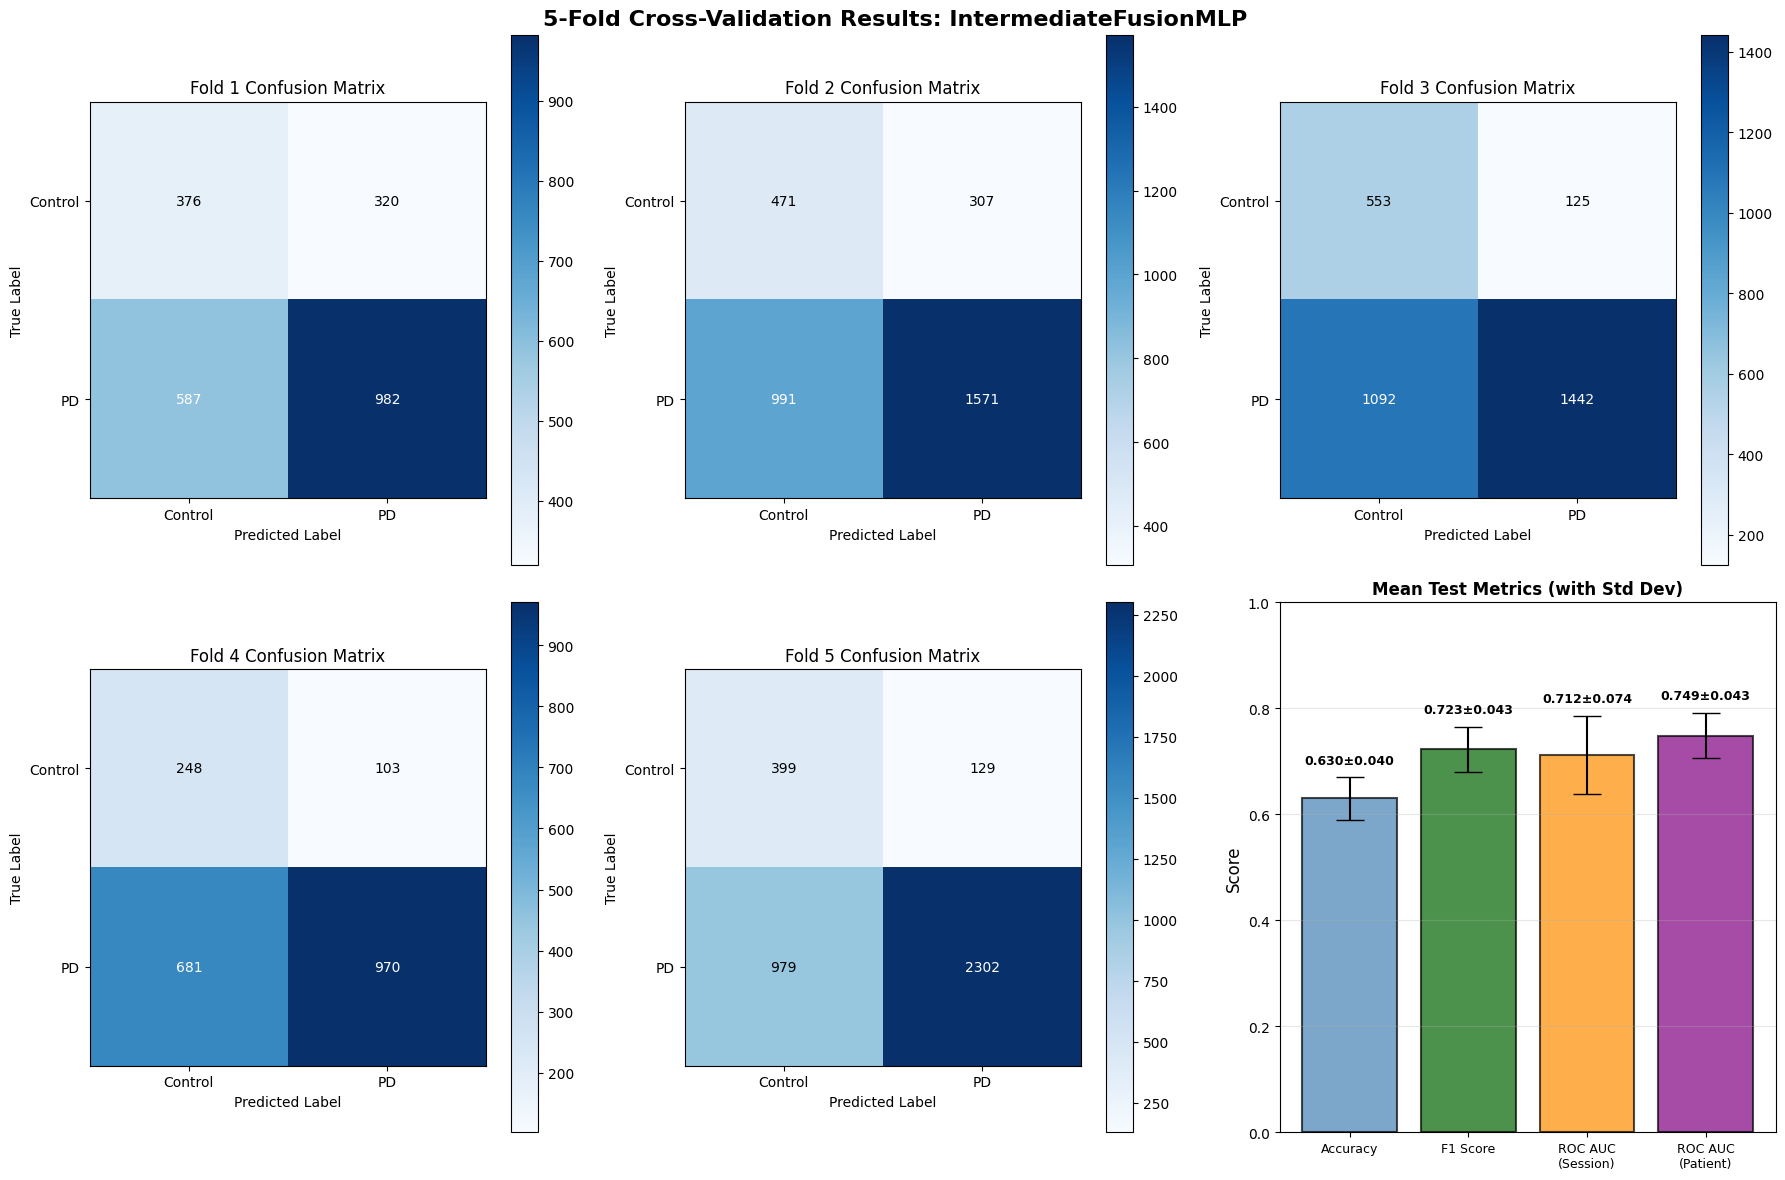


Summary Statistics:
Test Accuracy:            0.6299 ± 0.0402
Test F1 Score:            0.7226 ± 0.0428
Test ROC AUC (Session):   0.7121 ± 0.0735
Test ROC AUC (Patient):   0.7485 ± 0.0425


In [6]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('5-Fold Cross-Validation Results: IntermediateFusionMLP', fontsize=16, fontweight='bold')

# Plot confusion matrices for each fold
for i, cm in enumerate(results['confusion_matrices']):
    if i < 5:  # We have 5 folds
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # Plot confusion matrix as heatmap
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Fold {i + 1} Confusion Matrix')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for row_idx in range(cm.shape[0]):
            for col_idx in range(cm.shape[1]):
                ax.text(col_idx, row_idx, format(cm[row_idx, col_idx], 'd'),
                       ha="center", va="center",
                       color="white" if cm[row_idx, col_idx] > thresh else "black")
        
        # Set ticks
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Control', 'PD'])
        ax.set_yticklabels(['Control', 'PD'])

# Plot mean metrics with error bars in the last subplot
ax = axes[1, 2]
metrics = ['Accuracy', 'F1 Score', 'ROC AUC\n(Session)', 'ROC AUC\n(Patient)']
means = [results['mean_test_acc'], results['mean_test_f1'], 
         results['mean_test_roc_auc_session'], results['mean_test_roc_auc_patient']]
stds = [results['std_test_acc'], results['std_test_f1'], 
        results['std_test_roc_auc_session'], results['std_test_roc_auc_patient']]

x_pos = np.arange(len(metrics))
bars = ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
              color=['steelblue', 'darkgreen', 'darkorange', 'purple'], 
              ecolor='black', capsize=10, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Test Metrics (with Std Dev)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Test Accuracy:            {results['mean_test_acc']:.4f} ± {results['std_test_acc']:.4f}")
print(f"Test F1 Score:            {results['mean_test_f1']:.4f} ± {results['std_test_f1']:.4f}")
print(f"Test ROC AUC (Session):   {results['mean_test_roc_auc_session']:.4f} ± {results['std_test_roc_auc_session']:.4f}")
print(f"Test ROC AUC (Patient):   {results['mean_test_roc_auc_patient']:.4f} ± {results['std_test_roc_auc_patient']:.4f}")